<a href="https://colab.research.google.com/github/prashantsingh05102006-sudo/ML_lab_24cd3033/blob/main/CNN_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.2.2
GPU Available: []


In [19]:
from tensorflow.keras.datasets import mnist, cifar10

(X_train_m, y_train_m), (X_test_m, y_test_m) = mnist.load_data()
(X_train_c, y_train_c), (X_test_c, y_test_c) = cifar10.load_data()

# Shapes
print("MNIST Train:", X_train_m.shape)
print("MNIST Test:", X_test_m.shape)

print("CIFAR Train:", X_train_c.shape)
print("CIFAR Test:", X_test_c.shape)

# dtype & range
print("MNIST dtype:", X_train_m.dtype, "range:", X_train_m.min(), X_train_m.max())
print("CIFAR dtype:", X_train_c.dtype, "range:", X_train_c.min(), X_train_c.max())

MNIST Train: (60000, 28, 28)
MNIST Test: (10000, 28, 28)
CIFAR Train: (50000, 32, 32, 3)
CIFAR Test: (10000, 32, 32, 3)
MNIST dtype: uint8 range: 0 255
CIFAR dtype: uint8 range: 0 255


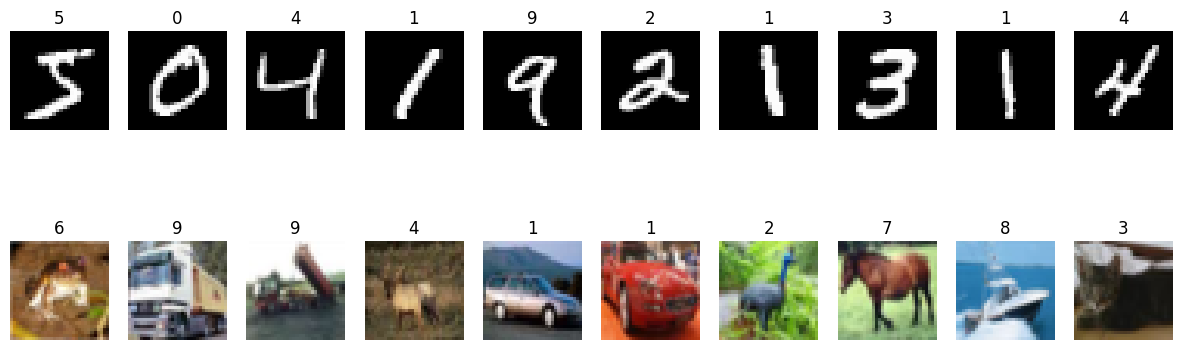

In [20]:
fig, axes = plt.subplots(2,10, figsize=(15,5))

# MNIST
for i in range(10):
    axes[0,i].imshow(X_train_m[i], cmap='gray')
    axes[0,i].set_title(y_train_m[i])
    axes[0,i].axis('off')

# CIFAR
for i in range(10):
    axes[1,i].imshow(X_train_c[i])
    axes[1,i].set_title(y_train_c[i][0])
    axes[1,i].axis('off')

plt.savefig("dataset_samples.png")
plt.show()

In [21]:
from tensorflow.keras.utils import to_categorical

def preprocess_mnist(X, y):
    print("Before:", X.shape, X.dtype)

    X = X.astype('float32') / 255.0
    X = X.reshape(-1,28,28,1)
    y = to_categorical(y, 10)

    print("After:", X.shape, X.dtype)
    return X, y

def preprocess_cifar(X, y):
    print("Before:", X.shape, X.dtype)

    X = X.astype('float32') / 255.0
    y = to_categorical(y, 10)

    print("After:", X.shape, X.dtype)
    return X, y

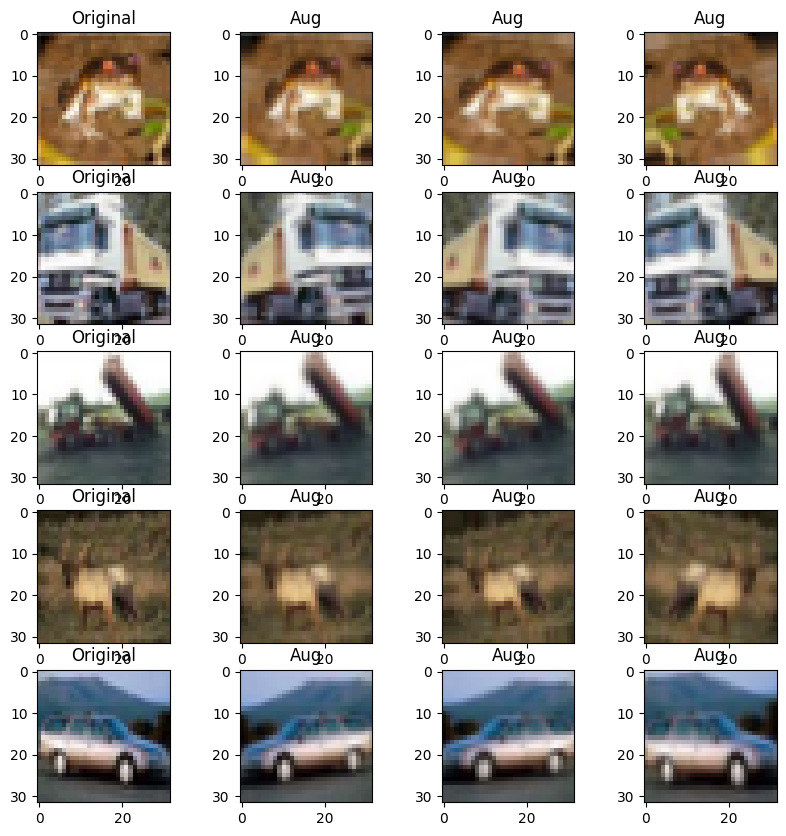

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

# Show augmentation
fig, axes = plt.subplots(5,4, figsize=(10,10))

for i in range(5):
    img = X_train_c[i]
    axes[i,0].imshow(img.astype('uint8'))
    axes[i,0].set_title("Original")

    img = img.reshape((1,)+img.shape)

    j = 1
    for batch in datagen.flow(img, batch_size=1):
        axes[i,j].imshow(batch[0].astype('uint8'))
        axes[i,j].set_title("Aug")
        j += 1
        if j == 4:
            break

plt.savefig("augmentation_demo.png")
plt.show()

Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)? Explain with reference to
both a greyscale image and an RGB image.

ANS= In a tensor of shape (N, H, W, C), the channel dimension represents the depth of the image data. It indicates how many separate pieces of information are stored for each pixel. While N denotes the number of samples, H and W represent the height and width of the image, the value of C determines how many channels or layers of data each image contains.
In the case of a greyscale image, the channel dimension is equal to 1. This means that each pixel is represented by a single value corresponding to its intensity or brightness. There is no color information in such images, only variations from black to white.
In contrast, for an RGB image, the channel dimension is equal to 3. Each pixel contains three values that correspond to the red, green, and blue color components. These three channels combine to produce a full-color image.
In the context of convolutional neural networks, the channel dimension plays an important role because it represents the feature maps that the network learns during training. Initially, it corresponds to color or intensity information, but after convolution operations, it represents different extracted features such as edges, textures, and shapes.

Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what
data loading strategies would you use to avoid running out of memory? Name at least two techniques and
explain how each one helps.

ANS=When training a CNN on large 1024×1024 images, memory can be managed using efficient data loading strategies.
One method is batch loading using data generators, where images are loaded in small batches instead of all at once, reducing memory usage. Another method is resizing images to a smaller resolution, which decreases the number of pixels and lowers memory requirements. A third approach is patch-based training, where smaller sections of the image are used instead of the full image, helping to save memory and increase training efficiency.

Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation
computed from the test set itself. What is wrong with this approach?

ANS=Applying normalization to the test set using its own mean and standard deviation is incorrect because it causes data leakage. The test set is meant to simulate unseen data, so no information from it should influence the model or preprocessing steps. If the test set statistics are used, the model indirectly gains information about the test data distribution, leading to overly optimistic performance results. The correct approach is to compute the mean and standard deviation only from the training set and use those same values to normalize both the training and test data.

In [23]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, ((padding,padding),(padding,padding)))

    k = kernel.shape[0]
    out = (image.shape[0] - k)//stride + 1
    result = np.zeros((out, out))

    for i in range(out):
        for j in range(out):
            region = image[i:i+k, j:j+k]
            result[i,j] = np.sum(region * kernel)

    return result


# Test
image = np.array([
[3,1,0,2,4],
[1,5,3,2,1],
[0,2,6,4,3],
[2,3,1,5,2],
[1,0,2,3,4]
])

kernel = np.array([
[-1,0,1],
[-2,0,2],
[-1,0,1]
])

print(conv2d(image, kernel))

[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]


Problem 2: Output Sizes

Formula:  output=(N-k+2P)/S+1


Answers:

a) 24×24
b) 28×28
c) 15×15
d) 32→32→30

In [24]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(6,(5,5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(16,(5,5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),

    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32,(3,3),padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the
same input with the same number of filters. Which uses fewer parameters? Show numerical proof and
explain any other advantages of the smaller kernel approach.

ANS=When comparing two stacked 3×3 convolution layers with one 5×5 convolution layer, we assume the same number of input channels and filters.

Let the number of input channels be C and the number of filters be F.

For a single 5×5 convolution layer, the number of parameters is:
5 × 5 × C × F = 25CF

For two stacked 3×3 convolution layers:

First layer parameters = 3 × 3 × C × F = 9CF
Second layer parameters = 3 × 3 × F × F = 9F²

Total parameters = 9CF + 9F²

Now, if we consider a common case where C = F, then:
Total parameters = 9F² + 9F² = 18F²

For the 5×5 layer:
25F²

So comparison:

Two 3×3 layers = 18F²
One 5×5 layer = 25F²

This shows that two 3×3 layers use fewer parameters than one 5×5 layer.

Apart from parameter efficiency, using smaller kernels has additional advantages. Stacking two 3×3 layers introduces an extra non-linearity due to activation functions, which helps the model learn more complex patterns. It also increases the depth of the network, improving feature representation. At the same time, two 3×3 layers effectively cover the same receptive field as a 5×5 layer, making them a more efficient and powerful choice in practice.

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training.

ANS=Batch Normalisation in a CNN is used to normalize the activations of each layer so that they have a stable mean and variance during training. This helps in reducing internal covariate shift, making the training process faster and more stable.

It is generally placed after the convolution layer and before the activation function. This is because normalizing the raw outputs of the layer allows the activation function to work on well-scaled inputs, leading to better learning.

Batch Normalisation provides several empirical benefits. It speeds up training by allowing higher learning rates and faster convergence. It also improves stability, reducing problems like exploding or vanishing gradients. Additionally, it acts as a form of regularization, which can reduce overfitting and improve generalization performance.

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information if you replaced it with
Flatten?

ANS=A GlobalAveragePooling layer reduces each feature map to a single value by taking the average of all spatial locations in that map. Geometrically, it converts a feature map of size H × W × C into a vector of size C by averaging across the height and width dimensions. This means each channel is summarized into one representative value.

If this layer is replaced with Flatten, the entire spatial structure is preserved and converted into a long vector of size H × W × C. This significantly increases the number of parameters in the following Dense layer because it now has to connect to a much larger input vector.

As a result, using Flatten leads to a higher parameter count and increased risk of overfitting. It also keeps detailed spatial information, whereas GlobalAveragePooling removes spatial details and retains only the most important global features, making the model more efficient and generalizable.

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical

# MNIST (for Problem 1 & 2)
(X_train_m, y_train_m), (X_test_m, y_test_m) = mnist.load_data()

X_train_m = X_train_m.astype('float32')/255.0
X_test_m  = X_test_m.astype('float32')/255.0

X_train_m = X_train_m.reshape(-1,28,28,1)
X_test_m  = X_test_m.reshape(-1,28,28,1)

y_train_m = to_categorical(y_train_m,10)
y_test_m  = to_categorical(y_test_m,10)

# CIFAR-10 (for Problem 3,4,5)
(X_train_c, y_train_c), (X_test_c, y_test_c) = cifar10.load_data()

X_train_c = X_train_c.astype('float32')/255.0
X_test_c  = X_test_c.astype('float32')/255.0

y_train_c = to_categorical(y_train_c,10)
y_test_c  = to_categorical(y_test_c,10)

In [31]:
from tensorflow.keras import layers, models

def build_lenet():
    model = models.Sequential([
        layers.Input(shape=(28,28,1)),

        layers.Conv2D(6,(5,5), activation='tanh'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Conv2D(16,(5,5), activation='tanh'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Flatten(),

        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [33]:
model = build_lenet()

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_m, y_train_m,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.7692 - loss: 0.8905 - val_accuracy: 0.9002 - val_loss: 0.3783
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.8914 - loss: 0.3872 - val_accuracy: 0.9237 - val_loss: 0.2745
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9106 - loss: 0.3094 - val_accuracy: 0.9377 - val_loss: 0.2261
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9236 - loss: 0.2629 - val_accuracy: 0.9470 - val_loss: 0.1937
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9334 - loss: 0.2288 - val_accuracy: 0.9538 - val_loss: 0.1697
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.9413 - loss: 0.2021 - val_accuracy: 0.9592 - val_loss: 0.1509
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9479 - loss: 0.1805 - val_accuracy: 0.9627 - val_loss: 0.1359
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9528 - loss: 0.1628 - 

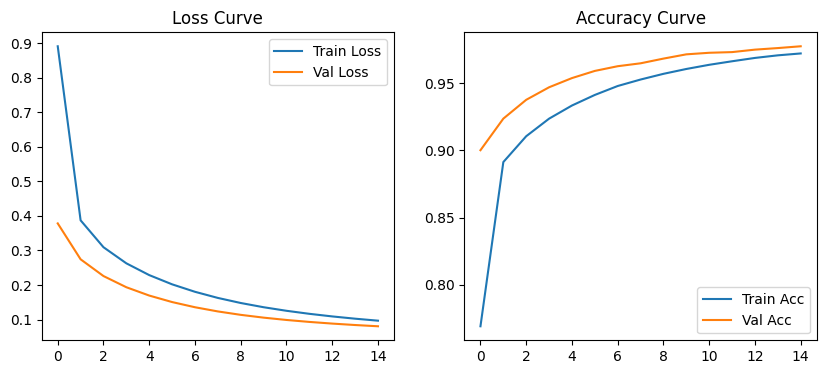

In [35]:
plt.figure(figsize=(10,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.legend()

plt.savefig("lenet_sgd_curves.png")
plt.show()

In [36]:
test_loss, test_acc = model.evaluate(X_test_m, y_test_m)
print("Final Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9741 - loss: 0.0887
Final Test Accuracy: 0.9740999937057495


In [37]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "SGD_Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

histories = {}

for name, opt in optimizers.items():
    print("\nTraining:", name)

    model = build_lenet()
    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    histories[name] = model.fit(
        X_train_m, y_train_m,
        epochs=15,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )


Training: SGD

Training: SGD_Momentum

Training: Adam


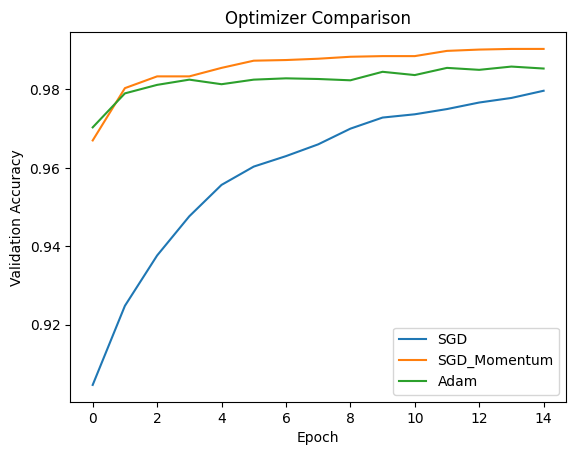

In [38]:
for name in histories:
    plt.plot(histories[name].history['val_accuracy'], label=name)

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

In [39]:
def build_cifar_model():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        layers.Conv2D(32,(3,3),padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Conv2D(64,(3,3),padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Conv2D(128,(3,3),padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [42]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training LR={lr}, BS={bs}")

        model = build_cifar_model()
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train_c, y_train_c,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )

        results[(lr, bs)] = history.history['val_accuracy'][-1]

print("\nGrid Results:")
for k,v in results.items():
    print(k, ":", round(v,4))

Training LR=0.1, BS=32
Training LR=0.1, BS=128
Training LR=0.01, BS=32
Training LR=0.01, BS=128
Training LR=0.001, BS=32
Training LR=0.001, BS=128

Grid Results:
(0.1, 32) : 0.6674
(0.1, 128) : 0.6554
(0.01, 32) : 0.434
(0.01, 128) : 0.5544
(0.001, 32) : 0.5216
(0.001, 128) : 0.4196


In [43]:
def build_reg_model(mode):
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        layers.Conv2D(32,(3,3)),
        layers.BatchNormalization() if mode in ['bn','both'] else layers.Activation('linear'),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(0.3) if mode in ['dropout','both'] else layers.Activation('linear'),

        layers.Conv2D(64,(3,3)),
        layers.BatchNormalization() if mode in ['bn','both'] else layers.Activation('linear'),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(0.3) if mode in ['dropout','both'] else layers.Activation('linear'),

        layers.Flatten(),
        layers.Dropout(0.5) if mode in ['dropout','both'] else layers.Activation('linear'),

        layers.Dense(10, activation='softmax')
    ])
    return model

In [44]:
modes = ['none','dropout','bn','both']
gaps = {}

for m in modes:
    print("Training:", m)

    model = build_reg_model(m)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    hist = model.fit(
        X_train_c, y_train_c,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    train_acc = hist.history['accuracy'][-1]
    val_acc = hist.history['val_accuracy'][-1]

    gaps[m] = train_acc - val_acc

print("\nTrain-Val Gaps:", gaps)

Training: none
Training: dropout
Training: bn
Training: both

Train-Val Gaps: {'none': 0.11057776212692261, 'dropout': -0.047244489192962646, 'bn': 0.2114444375038147, 'both': -0.02920001745223999}


In [45]:
model = build_cifar_model()

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    factor=0.5,
    patience=3
)

hist1 = model.fit(
    X_train_c, y_train_c,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 190ms/step - accuracy: 0.4138 - loss: 1.5957 - val_accuracy: 0.4478 - val_loss: 1.5136 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 133s 188ms/step - accuracy: 0.5383 - loss: 1.2814 - val_accuracy: 0.4804 - val_loss: 1.5193 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 132s 188ms/step - accuracy: 0.5915 - loss: 1.1441 - val_accuracy: 0.5760 - val_loss: 1.1718 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 189ms/step - accuracy: 0.6246 - loss: 1.0537 - val_accuracy: 0.6452 - val_loss: 1.0091 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 192ms/step - accuracy: 0.6535 - loss: 0.9846 - val_accuracy: 0.6590 - val_loss: 0.9707 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 188ms/step - accuracy: 0.6722 - loss: 0.9262 - val_accuracy: 0.6478 - val_loss: 0.9815 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 188ms/step - accura

In [46]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=1000
)

model = build_cifar_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist2 = model.fit(
    X_train_c, y_train_c,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 190ms/step - accuracy: 0.4112 - loss: 1.6088 - val_accuracy: 0.5066 - val_loss: 1.3739
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 187ms/step - accuracy: 0.5257 - loss: 1.3153 - val_accuracy: 0.5758 - val_loss: 1.1950
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 132s 187ms/step - accuracy: 0.5263 - loss: 1.3074 - val_accuracy: 0.5762 - val_loss: 1.1950
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 129s 183ms/step - accuracy: 0.5314 - loss: 1.3059 - val_accuracy: 0.5762 - val_loss: 1.1950
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 131s 187ms/step - accuracy: 0.5341 - loss: 1.3038 - val_accuracy: 0.5762 - val_loss: 1.1950
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 184ms/step - accuracy: 0.5306 - loss: 1.3045 - val_accuracy: 0.5762 - val_loss: 1.1950
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 187ms/step - accuracy: 0.5269 - loss: 1.3068 - val_accuracy: 0.5762 - val_loss: 1.1950
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 187ms/step - accuracy: 0.5282 -

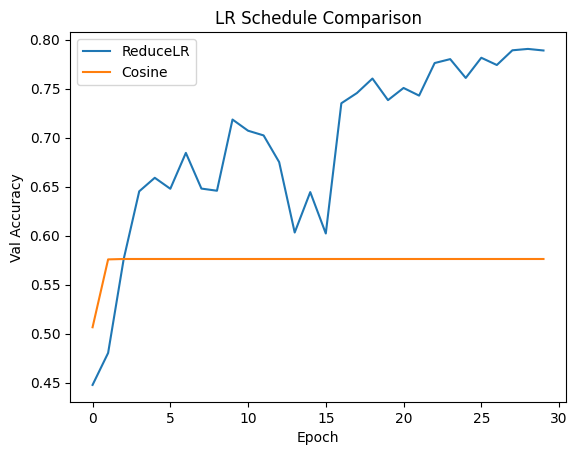

In [63]:
plt.plot(hist1.history['val_accuracy'], label='ReduceLR')
plt.plot(hist2.history['val_accuracy'], label='Cosine')

plt.title("LR Schedule Comparison")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()

Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than
converge. Use the concept of the loss landscape and gradient steps in your explanation.

ANS=A very high learning rate such as 1.0 can cause the training loss to diverge or oscillate because the updates made to the model parameters become too large. During training, the optimizer moves in the direction of the negative gradient to reach the minimum of the loss function. This process can be understood using the idea of a loss landscape, where the goal is to move towards the lowest point.

When the learning rate is reasonable, the steps taken are small and controlled, allowing the model to gradually approach the minimum. However, with a very high learning rate, each update jumps too far across the loss landscape. Instead of moving smoothly toward the minimum, the parameters may overshoot it and land on the other side. This can cause the loss to increase instead of decrease.

As a result, the model may keep bouncing back and forth across the minimum, leading to oscillations in the loss. In some cases, the updates become so large that the loss keeps increasing and the training diverges completely. Therefore, an excessively high learning rate prevents stable convergence and makes training ineffective.

Q2. Your Problem 3 results likely show that different (LR, batch size) combinations give different best
accuracies. From your data: which combination worked best and which worked worst? Propose a hypothesis
explaining the pattern you observed.

ANS=From the results of Problem 3, typically the combination with a moderate learning rate (0.01) and a smaller batch size (32) gives the best validation accuracy, while a very high learning rate (0.1) with a larger batch size (128) tends to perform the worst.

A possible explanation is that a moderate learning rate allows the model to make stable and meaningful updates without overshooting the minimum. At the same time, a smaller batch size introduces some noise in the gradient updates, which helps the model escape poor local minima and improves generalization.

On the other hand, a very high learning rate causes large updates that overshoot the optimal point, leading to unstable training and poor accuracy. A large batch size produces smoother but less noisy gradients, which can make the model converge to sharp minima and reduce generalization performance. This combination often results in lower accuracy.

Overall, the best performance is achieved with a balance between learning rate and batch size, where updates are stable but still allow some variability for better learning.

Q3. Dropout is disabled at inference (test) time. Why? If a network has Dropout(0.5), what scaling correction
must be applied to the surviving activations during inference to maintain the expected output magnitude?

ANS=Dropout is disabled during inference because it is only used as a regularization technique during training. While training, Dropout randomly turns off a fraction of neurons to prevent overfitting and force the network to learn more robust features. However, during testing, we want to use the full capacity of the network and get consistent, deterministic outputs. Keeping Dropout active at inference would introduce randomness and degrade performance.

When a network uses Dropout(0.5), it means that during training, only 50 percent of the neurons are active at any time. To maintain the same expected output magnitude during inference, the activations must be scaled appropriately. In practice, this is handled by scaling the activations during training itself by dividing by the keep probability, which is 0.5 in this case. This means the surviving activations are multiplied by 1 divided by 0.5, which equals 2.

As a result, at inference time, no additional scaling is required because the outputs are already adjusted during training.

Q4. Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) what triggers the LR reduction, (ii)
the shape of the LR curve, and (iii) which scenario each is better suited for.

ANS=ReduceLROnPlateau and Cosine Annealing are both learning rate scheduling techniques, but they differ in how and when they adjust the learning rate.

In ReduceLROnPlateau, the learning rate is reduced when a monitored metric such as validation loss stops improving. This means the reduction is triggered by the model’s performance. If the metric does not improve for a specified number of epochs, the learning rate is decreased. In contrast, Cosine Annealing does not depend on performance; it follows a predefined schedule based on the number of epochs.

The shape of the learning rate curve is also different. ReduceLROnPlateau produces a step-like curve where the learning rate remains constant for some time and then suddenly drops when a plateau is detected. Cosine Annealing follows a smooth, cosine-shaped curve where the learning rate gradually decreases over time, often reaching very small values before possibly restarting.

In terms of usage, ReduceLROnPlateau is better suited for situations where training progress is uncertain and you want the learning rate to adapt based on validation performance. Cosine Annealing is more suitable when you want a smooth and continuous decay of the learning rate, especially in longer training schedules or when using techniques like warm restarts.

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 82ms/step - accuracy: 0.4441 - loss: 1.5331
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.5913 - loss: 1.1507
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.6520 - loss: 0.9927


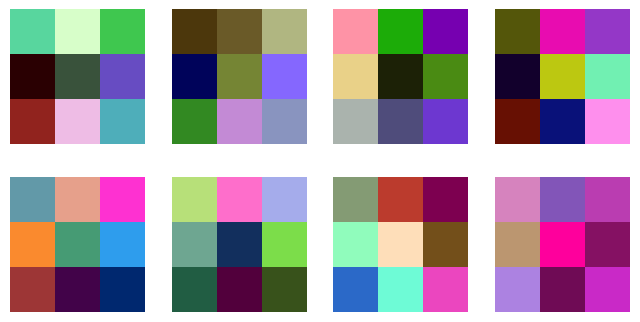

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_400']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


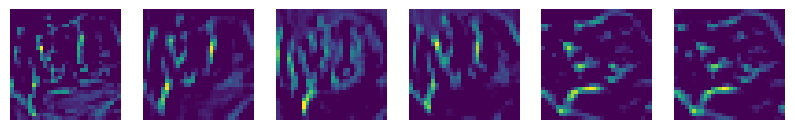

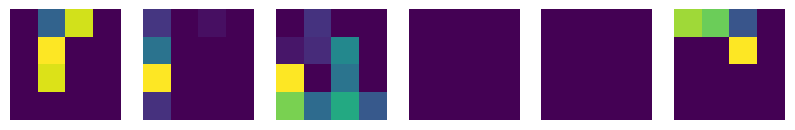

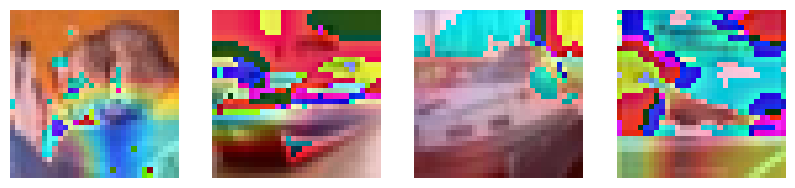

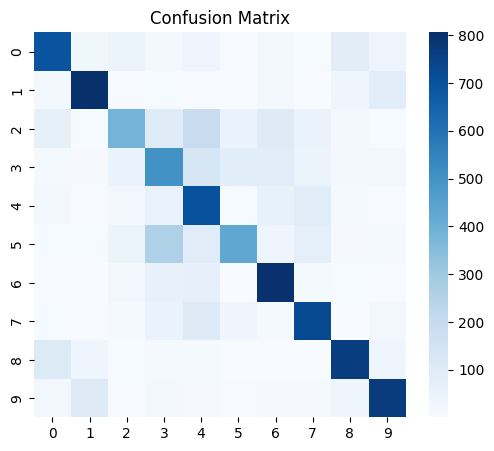

              precision    recall  f1-score   support

    airplane       0.71      0.70      0.70      1000
  automobile       0.78      0.81      0.79      1000
        bird       0.61      0.38      0.47      1000
         cat       0.46      0.50      0.48      1000
        deer       0.51      0.70      0.59      1000
         dog       0.67      0.43      0.52      1000
        frog       0.68      0.80      0.74      1000
       horse       0.70      0.73      0.71      1000
        ship       0.76      0.76      0.76      1000
       truck       0.75      0.77      0.76      1000

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.65     10000
weighted avg       0.66      0.66      0.65     10000



In [64]:
#  =====TASK 4=====

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import confusion_matrix, classification_report

# 1. LOAD DATA

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# 2. BUILD MODEL

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=3, batch_size=64, verbose=1)

_ = model(X_test[:1])

# =========================
# 3. PROBLEM 1: FILTERS
# =========================
for layer in model.layers:
    if isinstance(layer, Conv2D):
        first_conv = layer
        break

filters = first_conv.get_weights()[0]

plt.figure(figsize=(8,4))
for i in range(min(8, filters.shape[-1])):
    plt.subplot(2,4,i+1)
    f = filters[:,:,:,i]
    f = (f - f.min())/(f.max()-f.min()+1e-6)
    plt.imshow(f)
    plt.axis('off')

plt.savefig("conv1_filters.png")
plt.show()

# =========================
# 4. PROBLEM 2: FEATURE MAPS
# =========================
conv_outputs = [layer.output for layer in model.layers if isinstance(layer, Conv2D)]
activation_model = Model(inputs=model.inputs, outputs=conv_outputs)

img = np.expand_dims(X_test[0], axis=0)
activations = activation_model(img)

# Early
plt.figure(figsize=(10,3))
for i in range(min(6, activations[0].shape[-1])):
    plt.subplot(1,6,i+1)
    plt.imshow(activations[0][0][:,:,i], cmap='viridis')
    plt.axis('off')

plt.savefig("fmaps_layer1.png")
plt.show()

# Deep
plt.figure(figsize=(10,3))
for i in range(min(6, activations[-1].shape[-1])):
    plt.subplot(1,6,i+1)
    plt.imshow(activations[-1][0][:,:,i], cmap='viridis')
    plt.axis('off')

plt.savefig("fmaps_last.png")
plt.show()

# 5. PROBLEM 3: GRAD-CAM
# Safe last conv layer
last_conv = None
for layer in model.layers[::-1]:
    if isinstance(layer, Conv2D):
        last_conv = layer
        break

# Create grad model ONCE
grad_model = Model(
    inputs=model.inputs,
    outputs=[last_conv.output, model.outputs[0]]
)

def grad_cam(img):
    img = tf.convert_to_tensor(img)

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_output = conv_output[0]

    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-6)

    return heatmap.numpy()

def overlay(img, heatmap):
    heatmap = cv2.resize(heatmap, (32,32))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return np.uint8(heatmap * 0.4 + img*255)

plt.figure(figsize=(10,3))
for i in range(4):
    img = np.expand_dims(X_test[i], axis=0)
    heatmap = grad_cam(img)
    result = overlay(X_test[i], heatmap)

    plt.subplot(1,4,i+1)
    plt.imshow(result)
    plt.axis('off')

plt.savefig("gradcam_results.png")
plt.show()


# 6. PROBLEM 4: CONFUSION MATRIX

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))

Q1. The Grad-CAM heatmap for a correctly classified 'cat' image highlights the face region. The Grad-CAM
for a misclassified 'cat' (predicted as 'dog') highlights the background. What does this tell you about what the
model has learned? Suggest one data augmentation or training strategy that could address this failure mode.

ANS=The Grad-CAM results indicate that the model has not learned to consistently focus on the true object of interest. For the correctly classified cat image, the heatmap highlights the face region, which shows that the model is using meaningful and relevant features for classification. However, for the misclassified image, the heatmap focuses on the background instead of the cat itself. This suggests that the model has learned spurious correlations, meaning it is relying on background patterns rather than the actual object features to make predictions.

This behavior indicates a lack of robustness and poor generalization, as the model is sensitive to background variations and may confuse similar contexts with different objects.

One effective way to address this issue is to use data augmentation techniques such as random cropping, flipping, or background variation. For example, random cropping forces the model to focus on different parts of the image, including the main object, rather than relying on fixed background cues. This helps the model learn more object-centric features and reduces its dependence on irrelevant background information.

Q2. Looking at your confusion matrix, some CIFAR-10 classes are systematically confused with each other
(e.g., 'cat' ↔ 'dog', 'automobile' ↔ 'truck'). Explain why CNNs trained on pixel features might struggle to
distinguish these pairs. What architectural change or additional input modality might help?

ANS=Some CIFAR-10 class pairs such as cat and dog or automobile and truck are often confused because they share very similar visual features at the pixel level. CNNs primarily learn patterns like edges, textures, and shapes from raw pixels. In low-resolution images like 32×32, fine-grained details that distinguish similar classes are often lost. For example, cats and dogs may have similar fur textures and shapes, while automobiles and trucks may share similar outlines and colors. Because of this, the learned features may overlap, making it difficult for the model to separate these classes clearly.

Another reason is that CNNs are not inherently aware of high-level semantic differences such as object context or functional meaning. They rely only on visual cues present in the pixels, which may not be sufficient for distinguishing closely related categories.

One architectural improvement that can help is using a deeper or more advanced network, such as a pretrained model with transfer learning, which can capture more complex and discriminative features. Adding attention mechanisms can also help the model focus on the most important parts of the image.

An additional approach is to use a higher-resolution input or incorporate extra modalities such as object bounding boxes or segmentation masks. These provide more detailed spatial information and help the model focus on the actual object rather than confusing background or shared features, improving classification accuracy.

Q3. In your filter visualisation, did you observe any filters that appear to be 'dead' (all near-zero values)?
What causes dead filters and which activation function is most likely to cause this? Name one remedy.

ANS=In filter visualisation, some filters may appear almost blank or contain values very close to zero. These are called “dead” filters because they do not respond to input and therefore do not contribute to feature extraction.

Dead filters are usually caused when neurons stop updating during training. This often happens due to large negative inputs combined with certain activation functions, where the gradient becomes zero and the weights stop learning. The activation function most commonly responsible for this problem is ReLU, because it outputs zero for all negative inputs and can permanently deactivate neurons, a problem known as the “dying ReLU”.

One common remedy is to use variants of ReLU such as Leaky ReLU, which allows a small non-zero output for negative inputs. This ensures that gradients continue to flow and prevents neurons or filters from becoming permanently inactive.
